In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import control as ct
import cvxpy as cp
from gekko import GEKKO

In [34]:
rho, Cp, kw, AR, VR, mk, Cpk = 0.9342, 3.01, 4032, 0.215, 10, 5, 2.0
k10, k20, k30 = 1.287e12, 1.287e12, 9.043e9
EA1, EA2, EA3 = 9758.3, 9758.3, 8560
dH1, dH2, dH3 = 4.2, -11, -41.85
cA0, theta0 = 5.1, 130.0

In [35]:
def cstr(t, x, F, QK):
    cA, cB, theta, thetaK = x
    T = theta + 273.15

    k1 = k10 * np.exp(-EA1/T)
    k2 = k20 * np.exp(-EA2/T)
    k3 = k30 * np.exp(-EA3/T)

    dcA = F*(cA0 - cA) - k1*cA - k3*cA**2
    dcB = -F*cB + k1*cA - k2*cB
    dtheta = F*(theta0-theta) + (kw*AR/(rho*Cp*VR))*(thetaK-theta) - (k1*cA*dH1 + k2*cB*dH2 + k3*cA**2*dH3)/(rho*Cp)
    dthetaK = (QK + kw*AR*(theta-thetaK)) / (mk*Cpk)

    return [dcA, dcB, dtheta, dthetaK]

In [36]:
x0 = [1.24, 0.90, 134.14, 128.95]
F, QK = 18.83, -4495.7

In [37]:
sol = solve_ivp(cstr, [0, 2], x0, args=(F, QK), dense_output=True)
t = np.linspace(0, 2, 200)
x = sol.sol(t)

Final cB: 0.8995304008004587
Final theta: 134.14384510794048


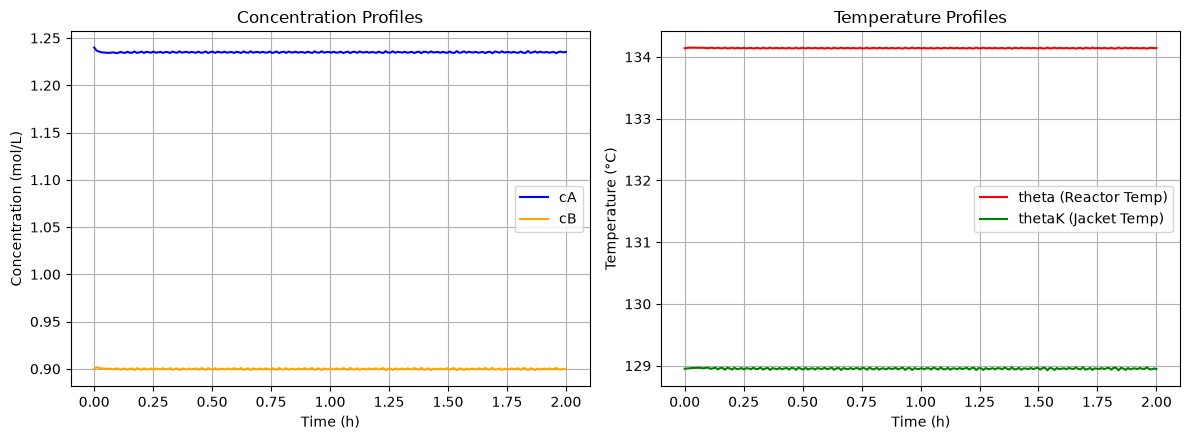

In [6]:
print("Final cB:", x[1][-1])
print("Final theta:", x[2][-1])
# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Concentrations (cA and cB)
ax1.plot(t, x[0], label="cA", color="blue")
ax1.plot(t, x[1], label="cB", color="orange")
ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Concentration (mol/L)")
ax1.set_title("Concentration Profiles")
ax1.legend()
ax1.grid(True)

# Plot 2: Temperatures (theta and thetaK)
ax2.plot(t, x[2], label="theta (Reactor Temp)", color="red")
ax2.plot(t, x[3], label="thetaK (Jacket Temp)", color="green")
ax2.set_xlabel("Time (h)")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title("Temperature Profiles")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [7]:
from scipy.optimize import fsolve

F_ss, QK_ss = 18.83, -4495.7
f = lambda x, F, QK: np.array(cstr(0, x, F, QK))

x_ss = fsolve(lambda x: f(x, F_ss, QK_ss), [1.24, 0.90, 134.14, 128.95])
print("x_ss =", x_ss)

x_ss = [  1.23482651   0.90000656 134.14035535 128.95428577]


In [8]:
def jacobian(fun, z0, eps=1e-6):
    n = len(fun(z0))
    J = np.zeros((n, len(z0)))
    for j in range(len(z0)):
        h = eps * max(1.0, abs(z0[j]))
        zp, zm = z0.copy(), z0.copy()
        zp[j] += h; zm[j] -= h
        J[:, j] = (fun(zp) - fun(zm)) / (2*h)
    return J

In [9]:
A = jacobian(lambda x: f(x, F_ss, QK_ss), x_ss.copy())
B = jacobian(lambda u: f(x_ss, u[0], u[1]), np.array([F_ss, QK_ss]))
C = np.array([[0,1,0,0],
              [0,0,1,0]], dtype=float)
D = np.zeros((2,2))

In [10]:
np.set_printoptions(precision=5, suppress=True, linewidth=150)
print("A =\n", A)
print("B =\n", B)
print("eig(A) =", np.linalg.eigvals(A))

A =
 [[-86.09525   0.       -4.20714   0.     ]
 [ 50.61563 -69.44563   0.99692   0.     ]
 [172.19441 198.00264 -36.77251  30.82852]
 [  0.        0.       86.688   -86.688  ]]
B =
 [[ 3.86517  0.     ]
 [-0.90001  0.     ]
 [-4.14036  0.     ]
 [ 0.       0.1    ]]
eig(A) = [ -16.79642  -54.83154  -86.33091 -121.04252]


In [11]:
G0 = D - C @ np.linalg.inv(A) @ B
print("G0 =\n", G0)
print("RGA =\n", G0 * np.linalg.inv(G0).T)

G0 =
 [[ 0.01117 -0.00004]
 [ 0.40408  0.00192]]
RGA =
 [[0.56526 0.43474]
 [0.43474 0.56526]]


In [12]:
n = 4
ctrb = np.hstack([np.linalg.matrix_power(A,i) @ B for i in range(n)])
obsv = np.vstack([C @ np.linalg.matrix_power(A,i) for i in range(n)])
print("rank ctrb:", np.linalg.matrix_rank(ctrb), " rank obsv:", np.linalg.matrix_rank(obsv))

rank ctrb: 4  rank obsv: 4


In [13]:
def cB_schedule(t):
    if t < 0.25:
        return 0.90
    elif t < 0.55:
        return 0.70
    else:
        return 0.95

In [38]:
def simulate_pi(Kp1, Ki1, Kp2, Ki2, func, theta_sp, t_final=0.8, dt=0.002):
    n = int(t_final/dt)
    x = x_ss.copy()
    I1 = I2 = 0.0
    t_h = np.zeros(n+1)
    x_h = np.zeros((n+1,4))
    u_h = np.zeros((n+1,2))
    x_h[0] = x; u_h[0] = [F_ss, QK_ss]
    for i in range(1, n+1):
        t = i*dt
        cB_sp = func(t)
        e1 = cB_sp - x[1]; e2 = theta_sp - x[2]
        F_raw = F_ss + Kp1*e1 + Ki1*(I1 + e1*dt)
        QK_raw = QK_ss + Kp2*e2 + Ki2*(I2 + e2*dt)
        F = np.clip(F_raw, 5, 35); QK = np.clip(QK_raw, -8500, 0)
        if F == F_raw: I1 += e1*dt  #integral term only when F and Q has not crossed its bound so there is no windup or no Accumulation
        if QK == QK_raw: I2 += e2*dt #integral term only when F and Q has not crossed its bound so there is no windup or no Accumulation
        sol = solve_ivp(cstr, [0, dt], x, args=(F, QK), method='LSODA', rtol=1e-8, atol=1e-10)
        x = sol.y[:, -1]
        t_h[i] = t; x_h[i] = x; u_h[i] = [F, QK]
    return t_h, x_h, u_h

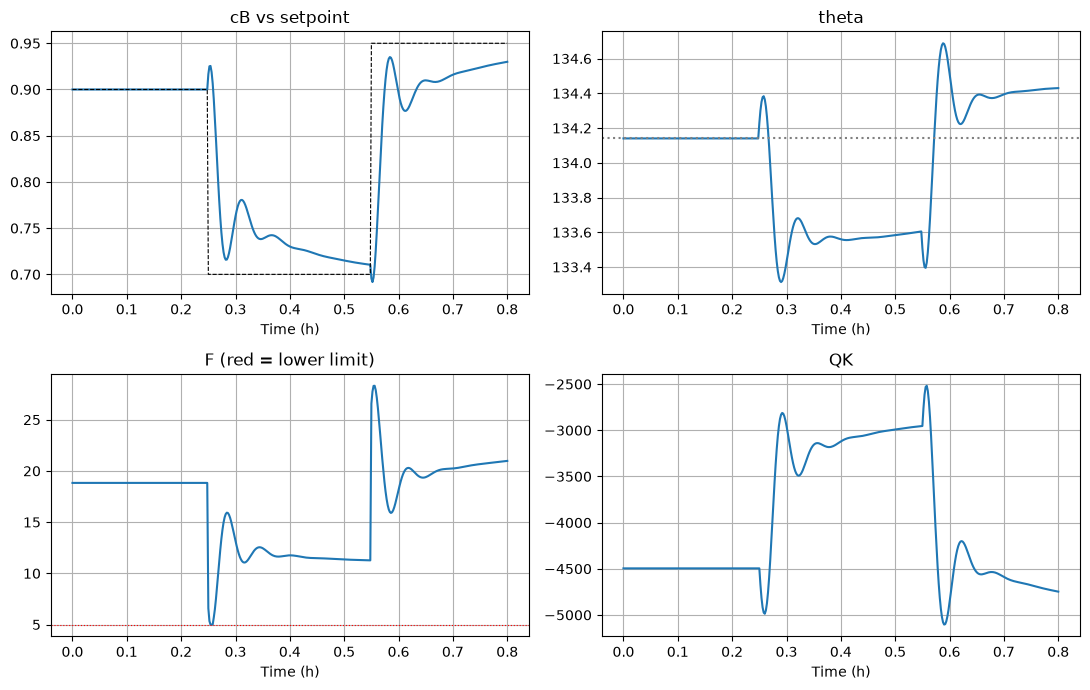

<Figure size 640x480 with 0 Axes>

In [39]:
t, x, u = simulate_pi(60, 600, 2000, 3000, cB_schedule, x_ss[2])

fig, axs = plt.subplots(2, 2, figsize=(11,7))
axs[0,0].plot(t, x[:,1]); axs[0,0].plot(t, [cB_schedule(ti) for ti in t], 'k--', lw=0.8)
axs[0,0].set_title("cB vs setpoint")
axs[0,1].plot(t, x[:,2]); axs[0,1].axhline(x_ss[2], color='gray', ls=':')
axs[0,1].set_title("theta")
axs[1,0].plot(t, u[:,0]); axs[1,0].axhline(5, color='red', ls=':', lw=0.8)
axs[1,0].set_title("F (red = lower limit)")
axs[1,1].plot(t, u[:,1]); axs[1,1].set_title("QK")
for ax in axs.flat: ax.grid(True); ax.set_xlabel("Time (h)")
plt.tight_layout(); plt.show()
plt.savefig("PID.png", dpi=150, bbox_inches='tight')

In [16]:
def equilibrium(cB_t, theta_t, guess):
    eqs = lambda p: f(np.array([p[0], cB_t, theta_t, p[1]]), p[2], p[3])
    return fsolve(eqs, guess)   # returns [cA, thetaK, F, QK]

targets = {
    0.90: equilibrium(0.90, 134.14, [1.235, 128.95, 18.83, -4495.7]),
    0.70: equilibrium(0.70, 134.14, [0.858, 125.0, 11.40, -2822]),
    0.95: equilibrium(0.95, 134.14, [1.356, 131.5, 21.65, -5076]),
}
print(targets)

{0.9: array([    1.23481,   128.95389,    18.82929, -4495.73483]), 0.7: array([    0.85769,   130.88448,    11.40203, -2822.1445 ]), 0.95: array([    1.35639,   128.28464,    21.6519 , -5075.89253])}


In [17]:
Q = np.diag([0.1, 100.0, 1.0, 0.01])
R = np.diag([1/30**2, 1/4000**2])
K, _, _ = ct.lqr(A, B, Q, R)
K = np.array(K)
print("K =\n", K)

K =
 [[  88.68959   80.88541   -0.14706    1.44574]
 [4591.68781 4204.53694 2751.78392  736.55102]]


In [40]:
def cB_target_now(t):
    if t < 0.25: return 0.90
    elif t < 0.55: return 0.70
    else: return 0.95

In [19]:
dt, t_final = 0.002, 0.8
x = x_ss.copy()
t_lqr, x_lqr, u_lqr = [0.0], [x.copy()], [[F_ss, QK_ss]]

for i in range(1, int(t_final/dt)+1):
    t = i*dt
    cB_r = cB_target_now(t)
    cA_r, thK_r, F_r, QK_r = targets[cB_r]
    xref = np.array([cA_r, cB_r, 134.14, thK_r])
    uref = np.array([F_r, QK_r])

    du = -K @ (x - xref)
    F  = np.clip(uref[0] + du[0], 5, 35)
    QK = np.clip(uref[1] + du[1], -8500, 0)

    sol = solve_ivp(cstr, [0, dt], x, args=(F, QK), method='LSODA')
    x = sol.y[:, -1]
    t_lqr.append(t); x_lqr.append(x.copy()); u_lqr.append([F, QK])

t_lqr = np.array(t_lqr); x_lqr = np.array(x_lqr); u_lqr = np.array(u_lqr)
print("final cB:", x_lqr[-1,1], " min cB:", x_lqr[:,1].min())

final cB: 0.949999999999539  min cB: 0.6749800149231052


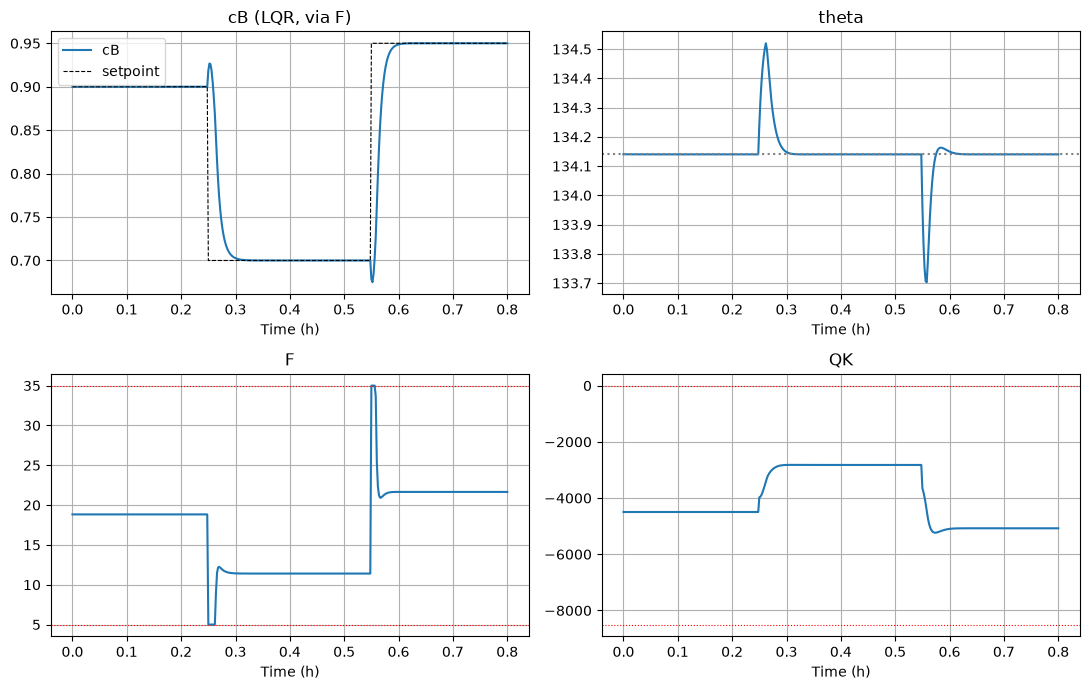

Final cB: 0.9500  (target 0.95)
min cB: 0.6750  (target 0.70)
F range: [5.00, 35.00]


In [32]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0,0].plot(t_lqr, x_lqr[:,1], label="cB")
axs[0,0].plot(t_lqr, [cB_schedule(ti) for ti in t_lqr], 'k--', lw=0.8, label="setpoint")
axs[0,0].set_title("cB (LQR, via F)"); axs[0,0].legend()

axs[0,1].plot(t_lqr, x_lqr[:,2])
axs[0,1].axhline(134.14, color='gray', ls=':')
axs[0,1].set_title("theta")

axs[1,0].plot(t_lqr, u_lqr[:,0])
axs[1,0].axhline(5, color='red', ls=':', lw=0.8)
axs[1,0].axhline(35, color='red', ls=':', lw=0.8)
axs[1,0].set_title("F")

axs[1,1].plot(t_lqr, u_lqr[:,1])
axs[1,1].axhline(-8500, color='red', ls=':', lw=0.8)
axs[1,1].axhline(0, color='red', ls=':', lw=0.8)
axs[1,1].set_title("QK")

for ax in axs.flat:
    ax.grid(True); ax.set_xlabel("Time (h)")
plt.tight_layout()
plt.savefig("LQR.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Final cB: {x_lqr[-1,1]:.4f}  (target 0.95)")
print(f"min cB: {x_lqr[:,1].min():.4f}  (target 0.70)")
print(f"F range: [{u_lqr[:,0].min():.2f}, {u_lqr[:,0].max():.2f}]")

In [21]:
Ts = 0.005
sys_c=ct.ss(A,B,C,D)
sysd = ct.c2d(sys_c, Ts)
Ad, Bd = np.array(sysd.A), np.array(sysd.B)

In [22]:
N = 20
Qw = np.diag([0.1, 100.0, 1.0, 0.01])
Rw = np.diag([1/30**2, 1/4000**2])
THETA_MAX = 134.3

In [23]:
def mpc_move(x_now, xref, uref):
    dx = cp.Variable((4, N+1))
    du = cp.Variable((2, N))

    cost = sum(cp.quad_form(dx[:,k], Qw) + cp.quad_form(du[:,k], Rw) for k in range(N))
    cost += cp.quad_form(dx[:,N], Qw)

    cons = [dx[:,0] == x_now - xref]
    for k in range(N):
        cons += [dx[:,k+1] == Ad@dx[:,k] + Bd@du[:,k],
                 uref[0]+du[0,k] >= 5,     uref[0]+du[0,k] <= 35,
                 uref[1]+du[1,k] >= -8500, uref[1]+du[1,k] <= 0,
                 xref[2]+dx[2,k+1] <= THETA_MAX]

    cp.Problem(cp.Minimize(cost), cons).solve(solver=cp.CLARABEL)
    return uref + du.value[:,0]

In [24]:
dt, t_final = 0.005, 0.8
x = x_ss.copy()
t_mpc, x_mpc, u_mpc = [0.0], [x.copy()], [[F_ss, QK_ss]]

for i in range(1, int(t_final/dt)+1):
    t = i*dt
    cB_r = cB_target_now(t)
    cA_r, thK_r, F_r, QK_r = targets[cB_r]
    xref = np.array([cA_r, cB_r, 134.14, thK_r])
    uref = np.array([F_r, QK_r])

    u = mpc_move(x, xref, uref)
    F  = np.clip(u[0], 5, 35)
    QK = np.clip(u[1], -8500, 0)

    x = solve_ivp(cstr, [0, dt], x, args=(F, QK), method='LSODA').y[:, -1]
    t_mpc.append(t); x_mpc.append(x.copy()); u_mpc.append([F, QK])

t_mpc = np.array(t_mpc); x_mpc = np.array(x_mpc); u_mpc = np.array(u_mpc)

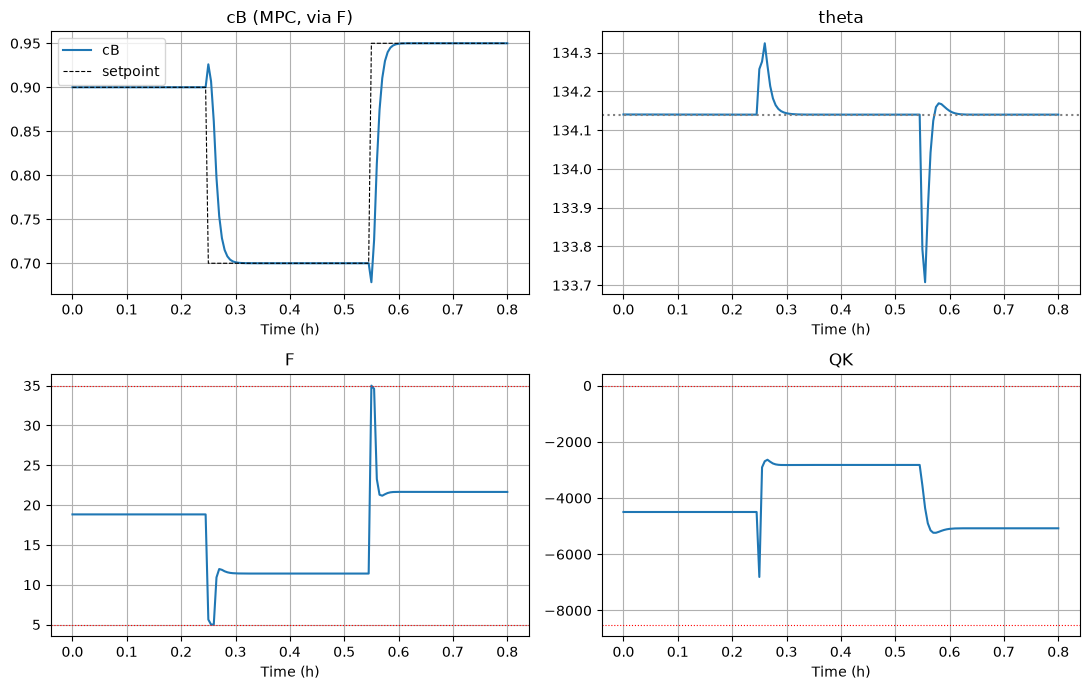

Final cB: 0.9500  (target 0.95)
min cB: 0.6785  (target 0.70)
F range: [5.00, 35.00]
theta range: [133.71, 134.32]


<Figure size 640x480 with 0 Axes>

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0,0].plot(t_mpc, x_mpc[:,1], label="cB")
axs[0,0].plot(t_mpc, [cB_schedule(ti) for ti in t_mpc], 'k--', lw=0.8, label="setpoint")
axs[0,0].set_title("cB (MPC, via F)"); axs[0,0].legend()

axs[0,1].plot(t_mpc, x_mpc[:,2])
axs[0,1].axhline(134.14, color='gray', ls=':')
axs[0,1].set_title("theta")

axs[1,0].plot(t_mpc, u_mpc[:,0])
axs[1,0].axhline(5, color='red', ls=':', lw=0.8)
axs[1,0].axhline(35, color='red', ls=':', lw=0.8)
axs[1,0].set_title("F")

axs[1,1].plot(t_mpc, u_mpc[:,1])
axs[1,1].axhline(-8500, color='red', ls=':', lw=0.8)
axs[1,1].axhline(0, color='red', ls=':', lw=0.8)
axs[1,1].set_title("QK")

for ax in axs.flat:
    ax.grid(True); ax.set_xlabel("Time (h)")
plt.tight_layout()
plt.show()
plt.savefig("mpc.png", dpi=150, bbox_inches='tight')

print(f"Final cB: {x_mpc[-1,1]:.4f}  (target 0.95)")
print(f"min cB: {x_mpc[:,1].min():.4f}  (target 0.70)")
print(f"F range: [{u_mpc[:,0].min():.2f}, {u_mpc[:,0].max():.2f}]")
print(f"theta range: [{x_mpc[:,2].min():.2f}, {x_mpc[:,2].max():.2f}]")

In [41]:
m = GEKKO(remote=False)
N = 160
t_final = 0.8
m.time = np.linspace(0, t_final, N+1)

In [42]:
cA = m.Var(value=x_ss[0], lb=0)
cB = m.Var(value=x_ss[1], lb=0)
theta = m.Var(value=x_ss[2])
thetaK = m.Var(value=x_ss[3])
F = m.MV(value=F_ss, lb=5, ub=35); F.STATUS = 1; F.DCOST = 1e-4
QK = m.MV(value=QK_ss, lb=-8500, ub=0); QK.STATUS = 1; QK.DCOST = 1e-7
slack = m.Var(value=0, lb=0)   # soft constraint: how far theta is allowed over 134.3, heavily penalized

In [43]:
cB_sp_vals = np.where(m.time < 0.25, 0.90, np.where(m.time < 0.55, 0.70, 0.95))
cB_sp = m.Param(value=cB_sp_vals)

In [44]:
T = theta + 273.15
k1 = k10*m.exp(-EA1/T); k2 = k20*m.exp(-EA2/T); k3 = k30*m.exp(-EA3/T)
m.Equation(cA.dt() == F*(cA0-cA) - k1*cA - k3*cA**2)
m.Equation(cB.dt() == -F*cB + k1*cA - k2*cB)
m.Equation(theta.dt() == F*(theta0-theta) + (kw*AR/(rho*Cp*VR))*(thetaK-theta) - (k1*cA*dH1+k2*cB*dH2+k3*cA**2*dH3)/(rho*Cp))
m.Equation(thetaK.dt() == (QK + kw*AR*(theta-thetaK))/(mk*Cpk))
m.Equation(theta <= 134.3 + slack)
m.Equation(theta >= 130.0)

In [45]:
m.Obj(100*(cB-cB_sp)**2 + 1e5*slack**2)
m.options.IMODE = 6
m.options.SOLVER = 3
m.solve(disp=False)

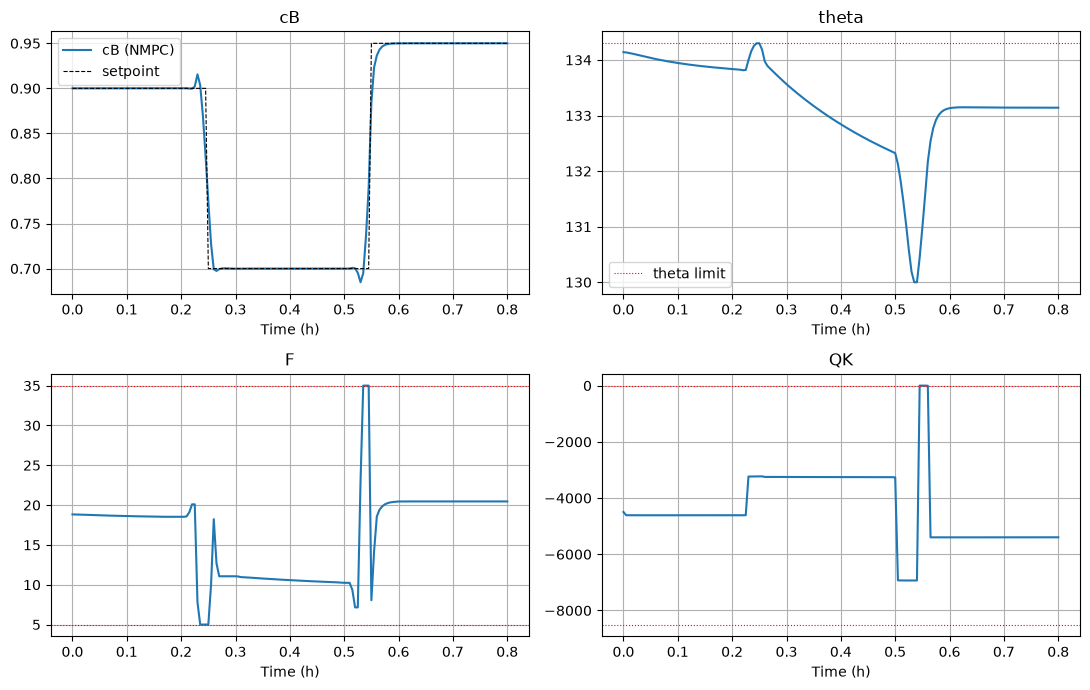

Final cB: 0.9500  (target 0.95)
min cB: 0.6849  (target 0.70)
theta range: [130.000, 134.3000]


In [46]:
cA_v = np.array(list(cA.value))
cB_v = np.array(list(cB.value))
theta_v = np.array(list(theta.value))
thetaK_v = np.array(list(thetaK.value))
F_v = np.array(list(F.value))
QK_v = np.array(list(QK.value))
t_v = np.array(m.time)

sched = np.where(t_v < 0.25, 0.90, np.where(t_v < 0.55, 0.70, 0.95))

fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0,0].plot(t_v, cB_v, label="cB (NMPC)")
axs[0,0].plot(t_v, sched, 'k--', lw=0.8, label="setpoint")
axs[0,0].set_title("cB"); axs[0,0].legend()

axs[0,1].plot(t_v, theta_v)
axs[0,1].axhline(134.3, color='red', ls=':', lw=0.8, label="theta limit")
axs[0,1].set_title("theta"); axs[0,1].legend()

axs[1,0].plot(t_v, F_v)
axs[1,0].axhline(5, color='red', ls=':', lw=0.8)
axs[1,0].axhline(35, color='red', ls=':', lw=0.8)
axs[1,0].set_title("F")

axs[1,1].plot(t_v, QK_v)
axs[1,1].axhline(-8500, color='red', ls=':', lw=0.8)
axs[1,1].axhline(0, color='red', ls=':', lw=0.8)
axs[1,1].set_title("QK")

for ax in axs.flat:
    ax.grid(True); ax.set_xlabel("Time (h)")
plt.tight_layout()
plt.savefig("nmpc.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Final cB: {cB_v[-1]:.4f}  (target 0.95)")
print(f"min cB: {cB_v.min():.4f}  (target 0.70)")
print(f"theta range: [{theta_v.min():.3f}, {theta_v.max():.4f}]")

In [47]:
np.random.seed(0)
meas_noise_std = np.array([0.002, 0.02])    # sensor noise: cB (mol/L), theta (C)
Q_ekf = np.diag([1e-5, 1e-6, 1e-4, 1e-4])   # process noise - how much to trust the model
R_ekf = np.diag(meas_noise_std**2)           # measurement noise covariance

In [48]:
dt, t_final = 0.002, 0.8
x_true = x_ss.copy()
x_est = x_ss + np.array([0.15, -0.03, 0.5, -0.5])   # deliberately wrong starting guess
P = np.eye(4)*0.1

t_ekf = [0.0]
x_true_h = [x_true.copy()]
x_est_h = [x_est.copy()]

for i in range(1, int(t_final/dt)+1):
    t = i*dt
    cB_r = cB_target_now(t)
    cA_r, thK_r, F_r, QK_r = targets[cB_r]
    xref = np.array([cA_r, cB_r, 134.14, thK_r])
    uref = np.array([F_r, QK_r])

    # controller uses the ESTIMATE, never the true state
    du = -K @ (x_est - xref)
    F  = np.clip(uref[0] + du[0], 5, 35)
    QK = np.clip(uref[1] + du[1], -8500, 0)

    # advance the real reactor
    sol = solve_ivp(cstr, [0, dt], x_true, args=(F, QK), method='LSODA')
    x_true = sol.y[:, -1]

    # noisy sensor reading
    y_meas = C @ x_true + np.random.normal(0, meas_noise_std)

    # EKF predict
    sol_est = solve_ivp(cstr, [0, dt], x_est, args=(F, QK), method='LSODA')
    x_pred = sol_est.y[:, -1]
    A_lin = jacobian(lambda xx: f(xx, F, QK), x_est.copy())
    Ad_ekf = np.eye(4) + A_lin*dt
    P_pred = Ad_ekf @ P @ Ad_ekf.T + Q_ekf

    # EKF correct
    S = C @ P_pred @ C.T + R_ekf
    K_ekf = P_pred @ C.T @ np.linalg.inv(S)
    x_est = x_pred + K_ekf @ (y_meas - C @ x_pred)
    P = (np.eye(4) - K_ekf @ C) @ P_pred

    t_ekf.append(t)
    x_true_h.append(x_true.copy())
    x_est_h.append(x_est.copy())

t_ekf = np.array(t_ekf)
x_true_h = np.array(x_true_h)
x_est_h = np.array(x_est_h)

print(f"Final cB (true): {x_true_h[-1,1]:.4f}  (target 0.95)")
print(f"Final cA: true={x_true_h[-1,0]:.4f}  estimated={x_est_h[-1,0]:.4f}")
print(f"Final thetaK: true={x_true_h[-1,3]:.4f}  estimated={x_est_h[-1,3]:.4f}")

Final cB (true): 0.9499  (target 0.95)
Final cA: true=1.3581  estimated=1.3574
Final thetaK: true=128.2905  estimated=128.2848


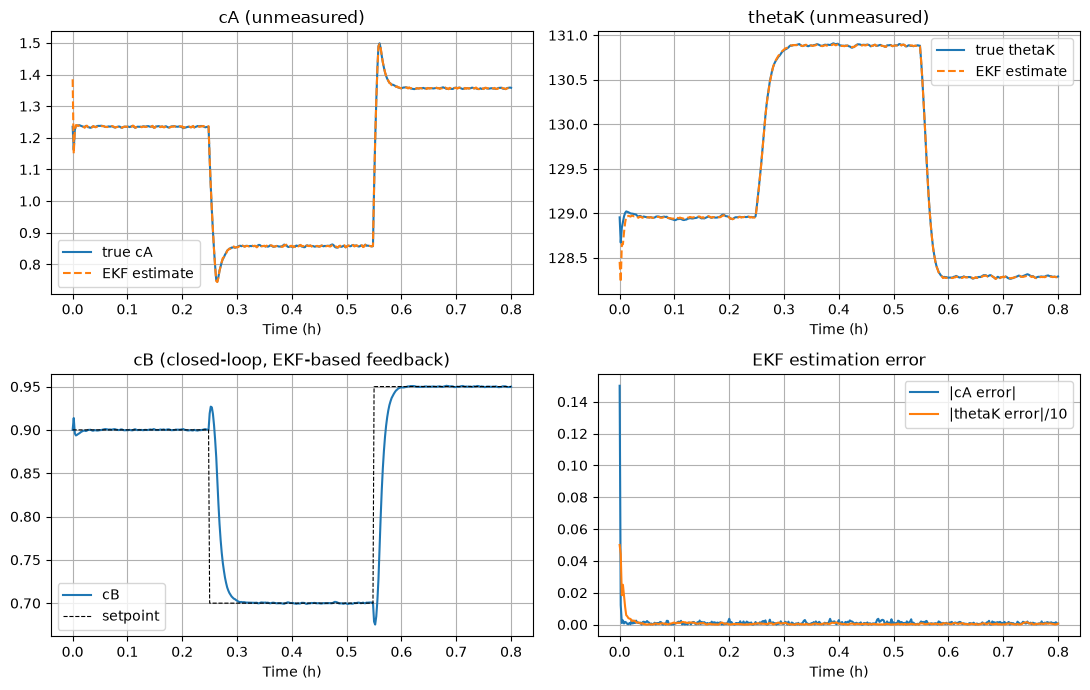

In [49]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0,0].plot(t_ekf, x_true_h[:,0], label="true cA")
axs[0,0].plot(t_ekf, x_est_h[:,0], '--', label="EKF estimate")
axs[0,0].set_title("cA (unmeasured)"); axs[0,0].legend()

axs[0,1].plot(t_ekf, x_true_h[:,3], label="true thetaK")
axs[0,1].plot(t_ekf, x_est_h[:,3], '--', label="EKF estimate")
axs[0,1].set_title("thetaK (unmeasured)"); axs[0,1].legend()

axs[1,0].plot(t_ekf, x_true_h[:,1], label="cB")
axs[1,0].plot(t_ekf, [cB_target_now(ti) for ti in t_ekf], 'k--', lw=0.8, label="setpoint")
axs[1,0].set_title("cB (closed-loop, EKF-based feedback)"); axs[1,0].legend()

axs[1,1].plot(t_ekf, np.abs(x_true_h[:,0]-x_est_h[:,0]), label="|cA error|")
axs[1,1].plot(t_ekf, np.abs(x_true_h[:,3]-x_est_h[:,3])/10, label="|thetaK error|/10")
axs[1,1].set_title("EKF estimation error"); axs[1,1].legend()

for ax in axs.flat:
    ax.grid(True); ax.set_xlabel("Time (h)")
plt.tight_layout()
plt.savefig("ekf.png", dpi=150, bbox_inches='tight')
plt.show()